# Introduction to Robotics (Lecture2)

articulated objects 可支持运动的物体如抽屉。  
运动学（今日重点）->动力学（调接口，此处不涉及）

6D pose：position + orientation

## Rigid Transformation
Link:
- Links are the rigid-body connected in sequence.

Joint:
- Joints are the connectors between links. （存在joint limits（lower&upper limits），但是受限于场景理论limit和真实limit可能不同）

DoF:
- The degree of freedom (DoF) of a mechanical system is the number of independent parameters that define its configuration.(每个关节对应一个自由度。科研中多为6-7个自由度，原因：为了让机器人能够以任意姿势去抓取任意位置的物体，它必须具备控制目标刚体 6 个变量（位置＋朝向）的能力，所以需要 6 个自由度。7自由度可以实现一些避障)
- free rigid body : 6DoF=3translation+3rotation
- 手指最后一个关节是under-actuated的，因为和上一个关节有关

tcp：tool center position(对于机械臂夹爪就是夹爪中心点)
### 坐标系转换
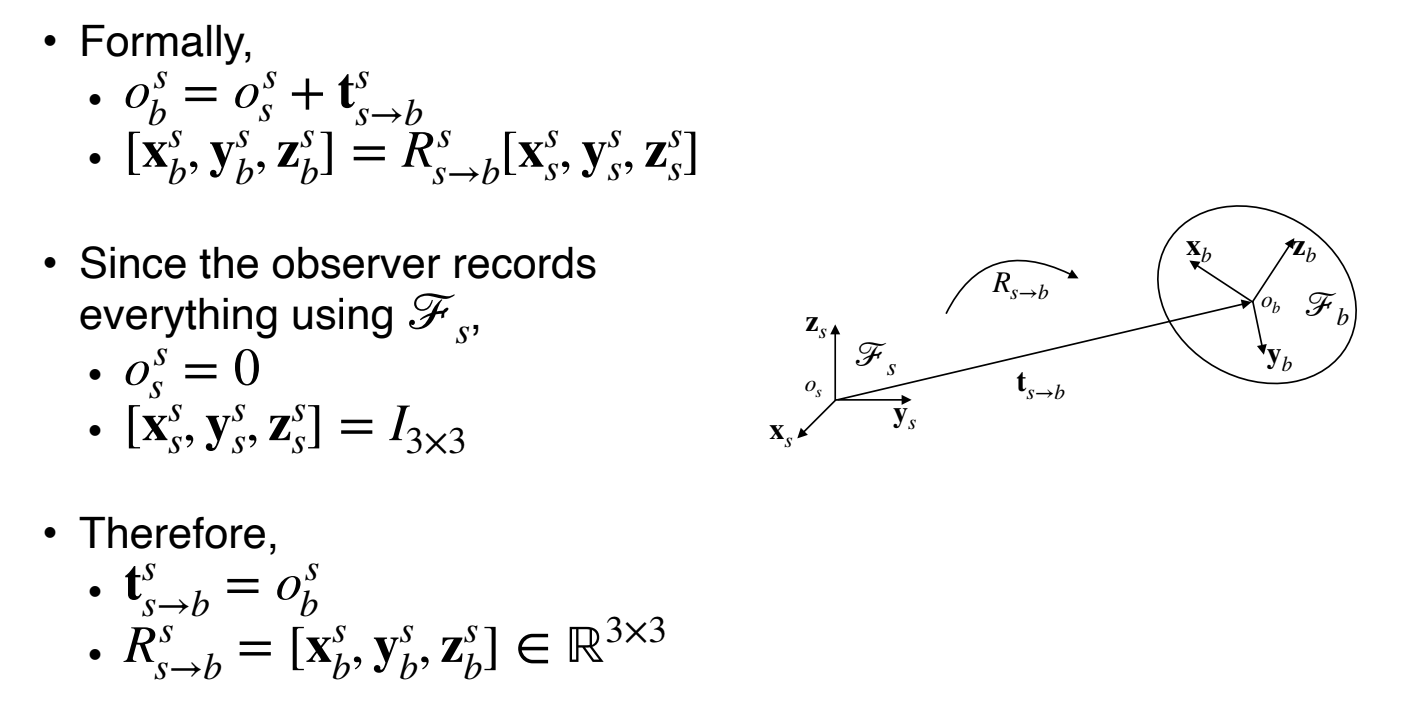
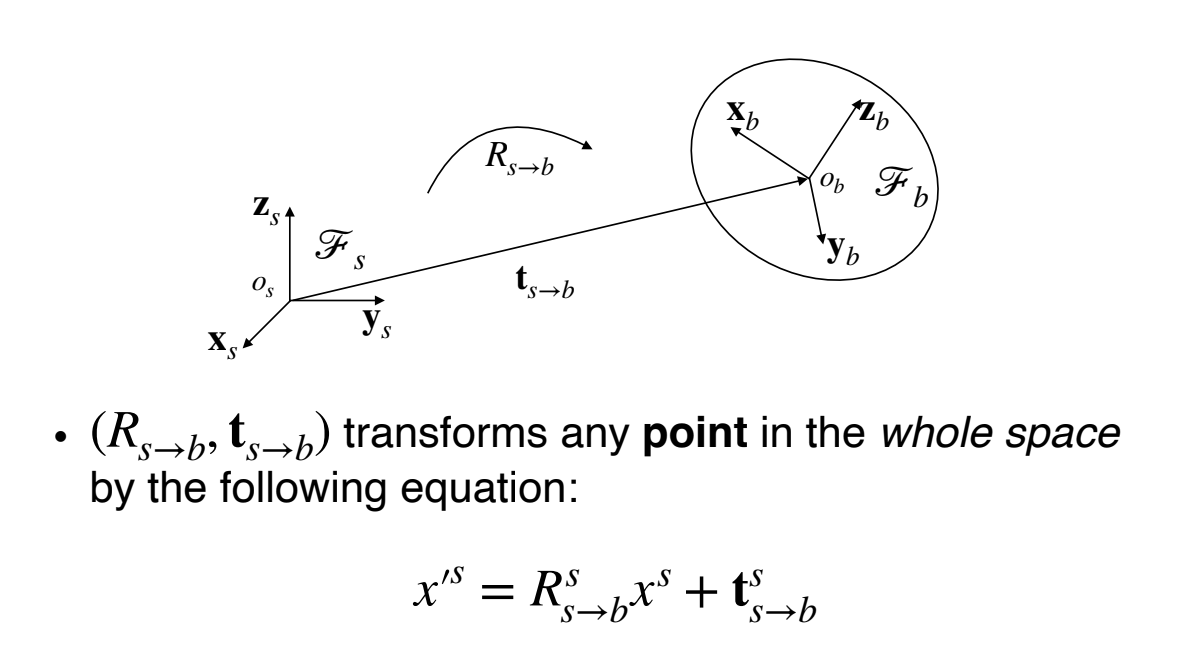
用齐次坐标简化：
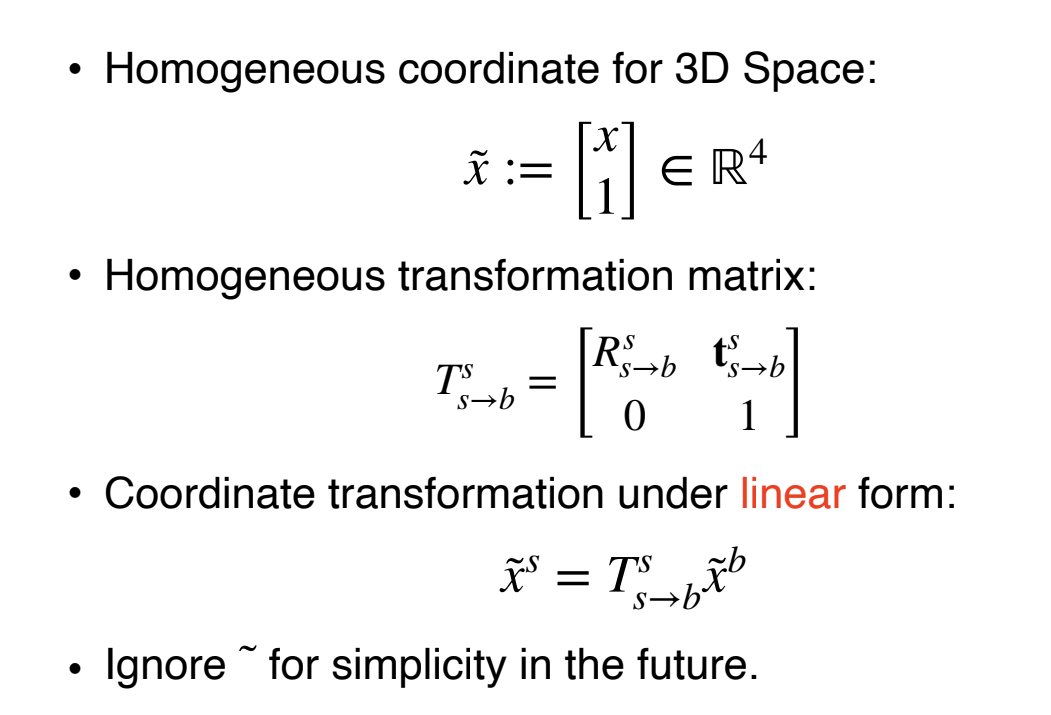

#### Example
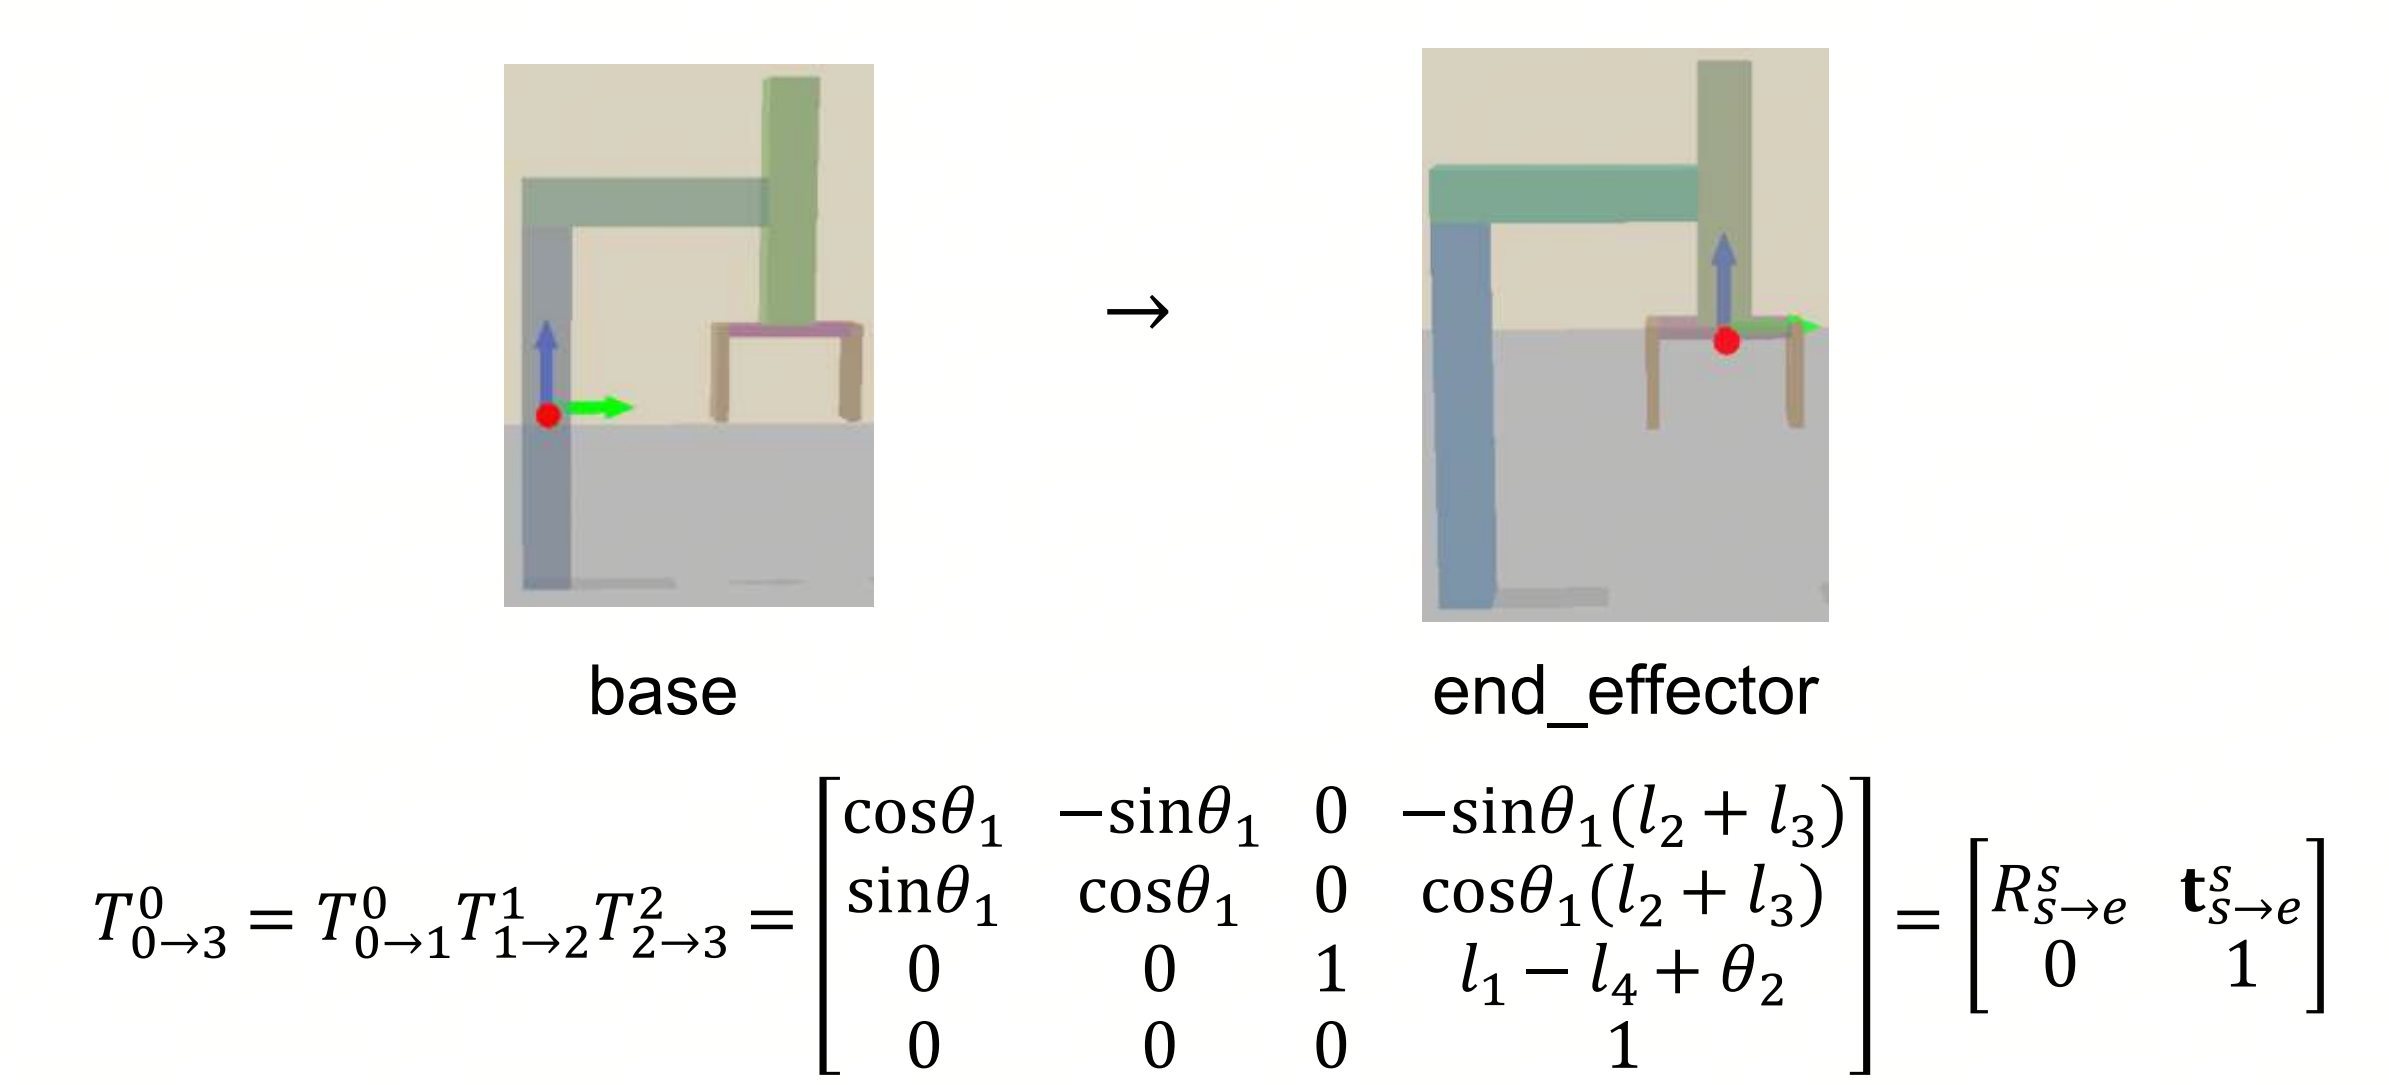
其中R，t就是endeffector简称ee的6Dpose，是eepose的一种表示形式————笛卡尔坐标系，又叫operation space。所有可能取得的θ1，θ2代入可以达到的位置构成reachable space。dexterous space（灵巧空间）是reachable space的子集，指达到这个位置并且可以在这个位置随意旋转。  
另一种表示方式就是给出θ1，θ2(qpos)，叫joint space，又叫configuration space

#### Forward Kinematics（FK）
由 θ 得到transformation matrix T
#### Inverse Kinematics（IK）
由transformation matrix T 得到 θ  
这个解不一定存在，存在也不一定唯一。解法一：数值解(这个过程需要定义一些限制)；解法二：解析解（Pieper’s criterion 当revolute axis平行或者相交于一点时有闭式解析解）

## Multi-Link Rigid-Body Geometry
### Joint types
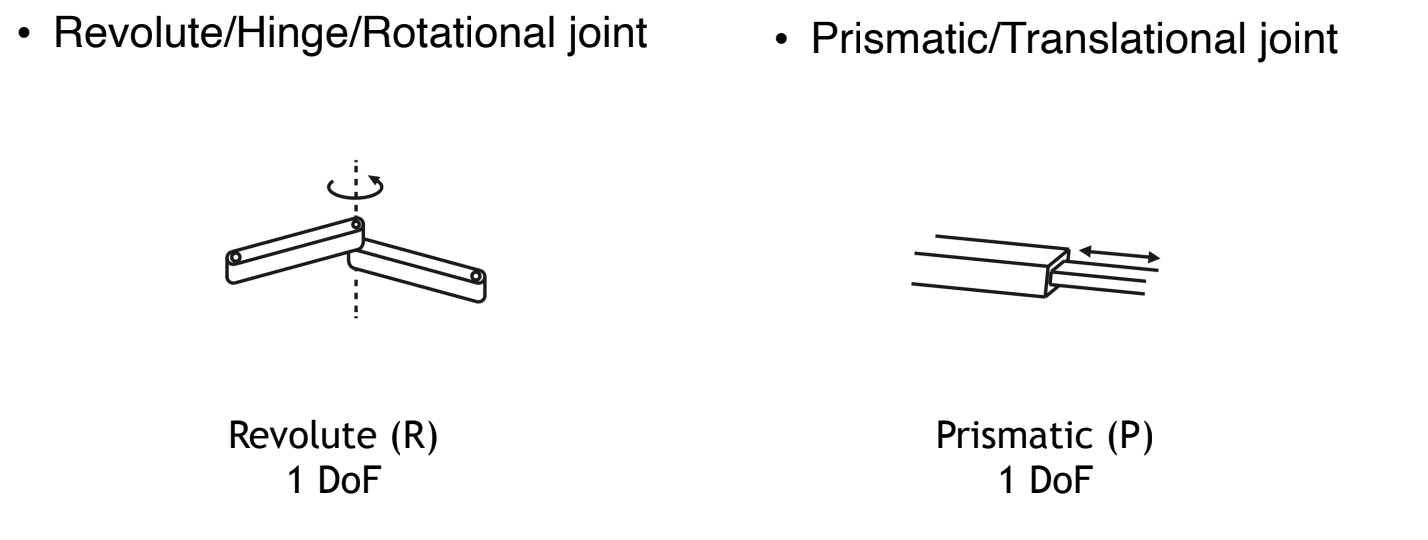

# 旋转表示 (Lecture 3)

## 1. 三维旋转的基础：特殊正交群 $SO(3)$

在描述刚体在三维空间中的方向时，我们实际上是在处理特殊正交群（Special Orthogonal Group）。

### 为什么 $SO(3)$ 是一个群？

#### 1. 什么是 $SO(3)$？
$SO(3)$ 全称是 **Special Orthogonal Group in 3 dimensions**（3 维特殊正交群）。
它是所有 **3D 旋转矩阵** 构成的集合。
数学定义为：
$$SO(3) = \{ R \in \mathbb{R}^{3 \times 3} \mid R^T R = I, \det(R) = 1 \}$$
*   $R^T R = I$：表示矩阵是正交的（保证旋转不改变长度，只改变方向）。
*   $\det(R) = 1$：表示行列式为 1（保证是纯旋转，不包含镜像反射）。

在机器人学中，$SO(3)$ 的**二元运算**定义为**矩阵乘法**。

#### 2. 验证 $SO(3)$ 满足群的四个公理

我们要证明：$(SO(3), \text{矩阵乘法})$ 是一个群。

**① 封闭性 (Closure)**
*   **假设**：有两个旋转矩阵 $A \in SO(3)$ 和 $B \in SO(3)$。
*   **验证**：它们的乘积 $C = AB$ 是否还在 $SO(3)$ 里？
    *   **正交性**：
        $$C^T C = (AB)^T (AB) = B^T A^T A B$$
        因为 $A \in SO(3)$，所以 $A^T A = I$。
        $$= B^T I B = B^T B$$
        因为 $B \in SO(3)$，所以 $B^T B = I$。
        即 $C^T C = I$，满足正交性。
    *   **行列式**：
        $$\det(C) = \det(AB) = \det(A) \cdot \det(B)$$
        因为 $\det(A)=1, \det(B)=1$，所以 $\det(C) = 1 \cdot 1 = 1$。
*   **结论**：$AB$ 仍然是一个合法的旋转矩阵。**封闭性成立。**
    *(物理意义：先旋转 A，再旋转 B，结果依然是一个旋转，不会变成缩放或剪切。)*

**② 结合律 (Associativity)**
*   **验证**：矩阵乘法本身就满足结合律。
    $$(AB)C = A(BC)$$
*   **结论**：**结合律成立。**
    *(物理意义：连续三次旋转，无论你是先算前两次的合成再转第三次，还是先算后两次的合成再转第一次，最终姿态是一样的。)*

**③ 单位元 (Identity)**
*   **验证**：是否存在一个 $3 \times 3$ 矩阵 $I$，使得 $IR = RI = R$？
    *   显然，$3 \times 3$ 的单位矩阵 $I = \begin{bmatrix} 1 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1 \end{bmatrix}$ 满足条件。
    *   检查 $I$ 是否属于 $SO(3)$：
        $I^T I = I$，且 $\det(I) = 1$。是的，它属于 $SO(3)$。
*   **结论**：**单位元存在。**
    *(物理意义：“不旋转”本身也是一种合法的旋转状态。)*

**④ 逆元 (Invertibility)**
*   **验证**：对于任意 $R \in SO(3)$，是否存在 $R^{-1} \in SO(3)$ 使得 $R R^{-1} = I$？
    *   对于正交矩阵，逆矩阵等于转置矩阵：$R^{-1} = R^T$。
    *   我们需要检查 $R^T$ 是否属于 $SO(3)$：
        *   正交性：$(R^T)^T (R^T) = R R^T = I$ （因为 $R$ 正交）。
        *   行列式：$\det(R^T) = \det(R) = 1$。
    *   所以 $R^T$ 也在 $SO(3)$ 集合中。
*   **结论**：**逆元存在。**
    *(物理意义：任何一个旋转，都可以通过反向旋转（转置矩阵）回到原点。)*

### SO(n) 和 SE(3)
*   **定义**：
    $$ SO(n) = \{ R \in \mathbb{R}^{n \times n} : \det(R) = 1, RR^T = I \} $$
    *   **Group (群)**：满足封闭性（closed under multiplication）。
    *   **Orthogonal (正交)**：$RR^T = I$，保证变换不改变向量长度（刚体性质）。
    *   **Special (特殊)**：$\det(R) = 1$，排除了镜像/反射，仅保留旋转。
    *   **Euclidean transformation 欧式变换**
    $$ SE(3) = \left\{ T = \begin{bmatrix} R & t \\ 0 & 1 \end{bmatrix} \mid R \in SO(3), t \in \mathbb{R}^3 \right\} $$
    $$ SE(3) = \{ (R, t) \mid R \in SO(3), t \in \mathbb{R}^3 \} $$
*   **自由度 (DoF)**：
    *   $SO(2)$：2D旋转，1个自由度。
    *   $SO(3)$：3D旋转，3个自由度。
*   **Distance between Rotations**:
    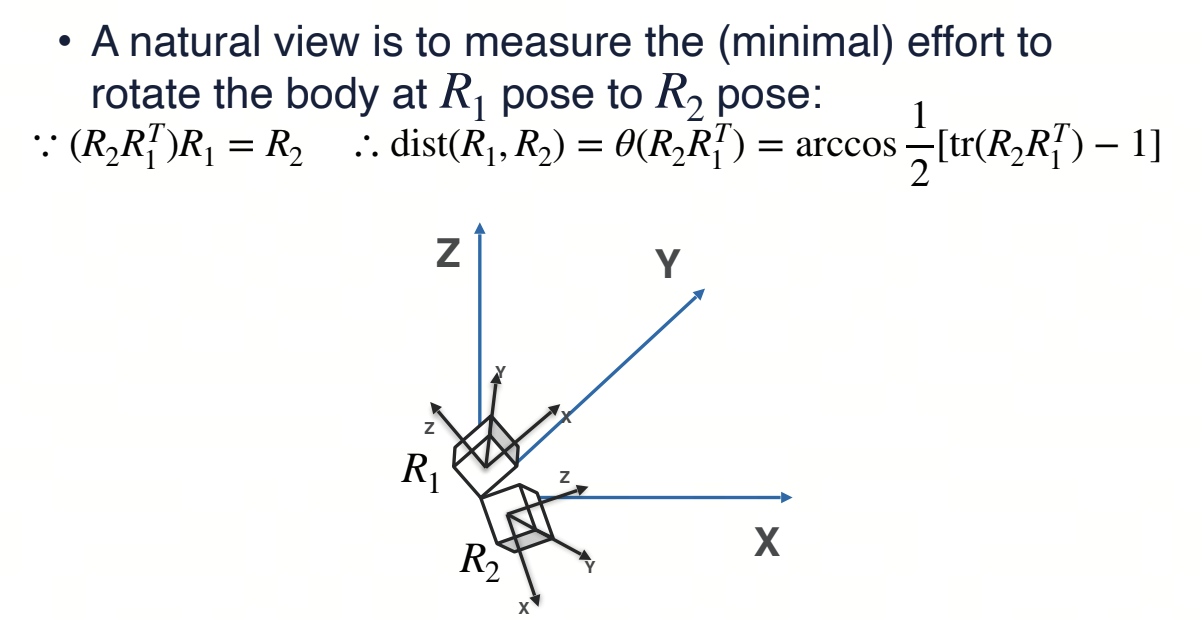
---

## 2. 旋转的表示方法 (Representations)

为了在计算机中处理 $SO(3)$，我们需要具体的参数化方法。课件对比了四种主要方式。

### 2.1 旋转矩阵 (Rotation Matrix)
*   **形式**：$3 \times 3$ 矩阵。
*   **缺点**：
    1.  **冗余与低效**：只有3个自由度，但使用了9个数值。
    2.  **数值稳定性差**：在连续计算中，由于浮点误差，矩阵容易失去正交性（$\det(R) \neq 1$），需要频繁修正。

### 2.2 欧拉角 (Euler Angle)
*   **形式**：将旋转分解为沿三个轴（如 Yaw偏航绕z轴-Pitch俯仰绕y'轴-Roll翻滚绕x''轴）的顺序旋转。
*   **优点**：非常直观，易于人类理解。
*   **缺点：万向节死锁 (Gimbal Lock)失去与R的一一对应性，有奇点+从A到B的线性插值真实旋转效果并不圆滑**
    *   **现象**：当中间轴旋转 $\pi/2$ 时，第一个轴和第三个轴重合，导致失去一个自由度。
    *   **数学示例**：若 $\beta = \pi/2$，旋转序列 $R = R_z(\alpha)R_y(\pi/2)R_x(\gamma)$ 会退化，$\alpha$ 和 $\gamma$ 的变化产生相同的效果。

### 2.3 轴-角表示 (Axis-Angle)
基于 **Euler's Theorem**：任何旋转都等价于绕某个固定轴 $\hat{\omega}$ ($\|\hat{\omega}\|=1$) 旋转角度 $\theta$。

*   **指数映射 (Exponential Map)**：
    利用矩阵指数定义旋转：
    $$ Rot(\hat{\omega}, \theta) \equiv e^{[\hat{\omega}]\theta} $$
    其中 $[\hat{\omega}]$ 是向量 $\hat{\omega}$ 的反对称矩阵。
*   **Rodrigues Formula (罗德里格斯公式)**：
    $$ e^{[\hat{\omega}]\theta} = I + [\hat{\omega}]\sin\theta + [\hat{\omega}]^2(1 - \cos\theta) $$
*   **非唯一性问题**：
    1.  $(\hat{\omega}, \theta)$ 和 $(-\hat{\omega}, -\theta)$ 表示同一旋转。
    2.  当 $\theta=0$ 时，$\hat{\omega}$ 可以是任意值（奇异点）。


### 2.4 四元数 (Quaternion) 
四元数是机器人学和图形学中最优的旋转表示方法，它是复数的推广。

#### A. 定义与性质
*   **代数形式**：$q = w + x\mathbf{i} + y\mathbf{j} + z\mathbf{k}$，其中 $w$ 为实部，$(x, y, z)$ 为虚部。
*   **向量形式**：$q = (w, \vec{v})$，其中 $\vec{v} \in \mathbb{R}^3$。
*   **运算规则**：
    *   $\mathbf{i}^2 = \mathbf{j}^2 = \mathbf{k}^2 = \mathbf{i}\mathbf{j}\mathbf{k} = -1$
    *   非交换律：$\mathbf{i}\mathbf{j} = \mathbf{k} = -\mathbf{j}\mathbf{i}$ 等。
*   **乘法**：
    $$ q_1 q_2 = (w_1 w_2 - \vec{v}_1^T \vec{v}_2, \ w_1\vec{v}_2 + w_2\vec{v}_1 + \vec{v}_1 \times \vec{v}_2) $$
*   **共轭与逆**：
    *   共轭：$q^* = (w, -\vec{v})$
    *   模长：$\|q\|^2 = w^2 + \vec{v}^T\vec{v} = qq^*$
    *   逆：$q^{-1} = q^* / \|q\|^2$

#### B. 单位四元数表示旋转 (Unit Quaternion as Rotation)
仅使用**单位四元数** ($\|q\|=1$) 表示旋转。其几何意义是 4D 球面上的点。

1.  **与轴-角的转换**：
    $$ q = [\cos(\theta/2), \sin(\theta/2)\hat{\omega}] $$
    *   注意是 $\theta/2$，这是四元数特有的性质。
    *   反向转换：$\theta = 2\arccos(w)$。

2.  **旋转操作**：
    要旋转三维向量 $\vec{x}$，首先将其扩展为纯虚四元数 $x = (0, \vec{x})$，然后计算：
    $$ x' = q x q^{-1} = q x q^* $$

3.  **复合旋转**：
    先做 $q_1$ 旋转，再做 $q_2$ 旋转，等价于四元数乘法：
    $$ q_{net} = q_2 q_1 $$

4.  **双倍覆盖 (Double Covering)**：
    $q$ 和 $-q$ 表示完全相同的旋转。这意味着四元数空间是 $SO(3)$ 的双倍覆盖。

    ##### 1. 代数推导证明 (最直接的解释)

    四元数对向量的旋转是通过**共轭作用**（Conjugation）来定义的。

    假设我们有一个单位四元数 $q$，以及一个代表三维向量的纯虚四元数 $x = (0, \vec{v})$。
    旋转后的向量 $x'$ 的计算公式为：
    $$ x' = q x q^{-1} $$

    现在，我们尝试使用 $-q$ 来执行相同的旋转操作。
    令 $p = -q$。我们需要计算 $p x p^{-1}$。

    1.  首先看逆元：
        由于 $(-q)$ 也是单位四元数（模长为1），其逆元等于其共轭。
        $$ p^{-1} = (-q)^{-1} = (-q)^* = -(q^*) = -q^{-1} $$
        *(或者简单的理解：$(-1)^{-1} = -1$，常数可以提取出来)*

    2.  代入旋转公式：
        $$ \begin{aligned} x'_{new} &= p x p^{-1} \\ &= (-q) x (-q^{-1}) \end{aligned} $$

    3.  由于标量（Scalar, 这里是 -1）在四元数乘法中是可以交换位置并提取出来的：
        $$ \begin{aligned} x'_{new} &= (-1 \cdot q) \cdot x \cdot (-1 \cdot q^{-1}) \\ &= (-1) \cdot (-1) \cdot (q x q^{-1}) \\ &= 1 \cdot (q x q^{-1}) \\ &= q x q^{-1} \end{aligned} $$

    **结论**：
    $$ (-q) x (-q)^{-1} = q x q^{-1} $$
    无论你使用 $q$ 还是 $-q$，计算出的旋转后向量 $x'$ 是**完全一样**的。因此，它们代表相同的物理旋转。

    ##### 2. 几何直观解释 (物理意义)

    我们可以通过**轴-角表示**（Axis-Angle）与四元数的转换公式来理解这一现象。

    标准转换公式为：
    $$ q = \left[ \cos\left(\frac{\theta}{2}\right), \sin\left(\frac{\theta}{2}\right)\hat{\omega} \right] $$

    想象一个物体当前的旋转角度是 $\theta$。如果我们把物体再多转一圈（$360^\circ$ 或 $2\pi$ 弧度），物体在物理空间中的姿态是完全没有变化的（回到原位）。

    此时，新的旋转角变成了 $\theta' = \theta + 2\pi$。

    让我们看看这在四元数中发生了什么：

    $$ \begin{aligned} q' &= \left[ \cos\left(\frac{\theta + 2\pi}{2}\right), \sin\left(\frac{\theta + 2\pi}{2}\right)\hat{\omega} \right] \\ &= \left[ \cos\left(\frac{\theta}{2} + \pi\right), \sin\left(\frac{\theta}{2} + \pi\right)\hat{\omega} \right] \end{aligned} $$

    利用三角函数性质 $\cos(A+\pi) = -\cos(A)$ 和 $\sin(A+\pi) = -\sin(A)$：

    $$ \begin{aligned} q' &= \left[ -\cos\left(\frac{\theta}{2}\right), -\sin\left(\frac{\theta}{2}\right)\hat{\omega} \right] \\ &= - \left[ \cos\left(\frac{\theta}{2}\right), \sin\left(\frac{\theta}{2}\right)\hat{\omega} \right] \\ &= -q \end{aligned} $$

    **结论**：
    *   物理上旋转 $\theta$ 对应四元数 $q$。
    *   物理上旋转 $\theta + 360^\circ$（即同一姿态）对应四元数 $-q$。
    *   物理上旋转 $\theta + 720^\circ$（两圈）又变回了 $q$。

    这就是所谓的**双倍覆盖**：四元数的超球面（$S^3$）覆盖了三维旋转群（$SO(3)$）两次。

#### C. 四元数的优势
*   **存储紧凑**：4个浮点数（相比矩阵的9个）。
*   **计算高效**：乘法运算量少于矩阵乘法。
*   **数值稳定**：通过简单的归一化即可保持单位长度，避免误差累积。
*   **插值平滑**：支持 SLERP。

## 3. 四元数的进阶操作

### 3.1 距离度量 (Distance)
由于 $q$ 和 $-q$ 等价，两个旋转 $q_1, q_2$ 之间的距离定义为：
$$ \text{dist}(q_1, q_2) = 2 \arccos(|\langle q_1, q_2 \rangle|) = 2 \min \{ \langle q_1, q_2 \rangle, \langle q_1, -q_2 \rangle \} $$
这代表了 4D 球面上的最短测地线Geodesic path距离。

### 3.2 插值 (Interpolation) - SLERP
*   **线性插值 (Lerp)**：不适用，因为插值结果不在球面上（模长不为1），且角速度不均匀。
*   **球面线性插值 (SLERP)**：
    沿着单位四元数球面的大圆（Great Circle）进行插值，保证恒定的角速度。
    公式（当 $\psi$ 为两者夹角）：
    $$ \text{Slerp}(q_0, q_1, t) = \frac{q_0 \sin((1-t)\psi) + q_1 \sin(t\psi)}{\sin(\psi)} $$
    证明过程：Spherical linear interpolation (SLERP) naturally works in any dimension
    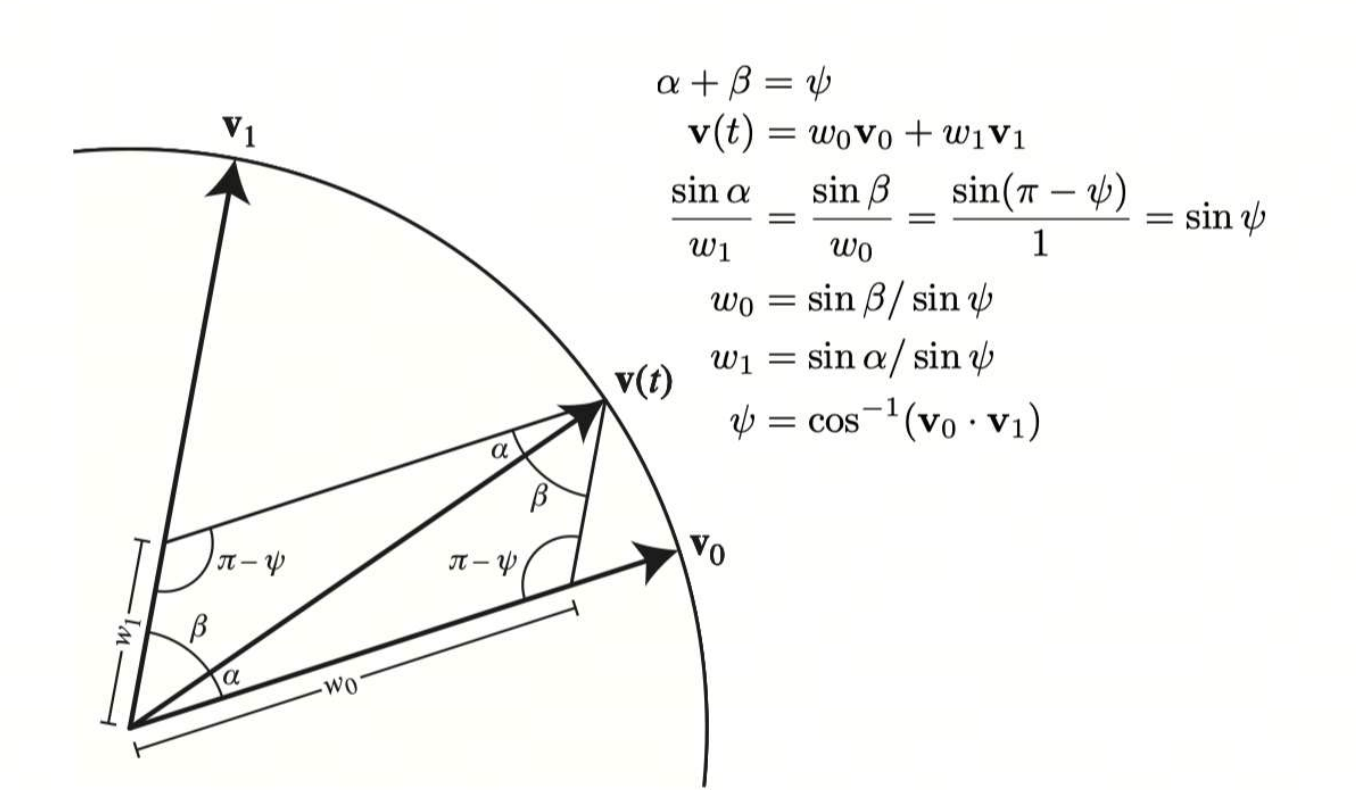

#### 对角度的特别说明
四元数本质上是 4 维空间里的一个长度为 1 的向量（点）。如果我们纯粹从代数/几何角度来看，两个 4 维单位向量的点乘，就**等于它们在 4D 空间中夹角的余弦值**。
我们把这个 4D 空间的夹角叫做 $\psi$：
$$ \text{dot} = q_1 \cdot q_2 = \cos(\psi) $$

##### 4Dvs3D角的关系 与 SLERP 公式

$$ \cos(\psi) = \cos(\frac{\theta_{3D}}{2}) \implies \psi = \frac{\theta_{3D}}{2} $$
**4D 空间里的夹角 $\psi$，刚好等于 3D 物理旋转角 $\theta_{3D}$ 的一半** 

SLERP 公式里的$\psi$，其实是 4D 空间的几何夹角，而不是 3D 物理角度 ！
    
#### **实践技巧**：
*   如果夹角非常小，退化为线性插值以避免除以零。
*   如果在球面上两点夹角 $>90^\circ$（点乘 $<0$），应取 $-q$ 进行插值，以走最短路径。
*   endeffector的6Dpose里面做slerp能够使得末端平滑运动；如果在joint space里面对每个关节的θ的线性插值，则是让关节均匀的运动，而ee不一定平滑运动。两者的选择根据具体实际需要选择，抓取一般是让endeffector平滑运动，跳舞则不太关心ee的情况。

### 3.3 均匀采样 (Uniform Sampling)
如何在 $SO(3)$ 上均匀采样随机旋转？
*   方法：从标准正态分布 $\mathcal{N}(0, I_{4\times4})$ 中采样4个数值，然后归一化得到单位四元数。
*   原理：各向同性的高斯分布在归一化后产生球面上的均匀分布。标准正态分布 $\mathcal{N}(0, 1)$ **各向同性 (Isotropy)**。如果在纸上画一个坐标系，X 轴和 Y 轴都服从标准正态分布。这些点会形成一个**圆形的云团**，中间密，四周疏。这个云团是完美的圆形的，没有“棱角”。如果你站在原点看这些点，**它们出现在任何一个角度的概率是完全相等的**。这个性质在 4 维空间同样成立。如果你生成 4 个标准正态分布的随机数，它们组成的向量，其**方向**在 4 维空间里是完全随机均匀的。由于我们只需要“方向”，不需要“长度”（单位四元数长度必须为 1）。所以，把这个向量除以它的模长（归一化），就把点“推”到了球面上。
*   **逻辑链条**：
$$ \text{4个高斯随机数} \rightarrow \text{归一化} \rightarrow \text{4维球面上的均匀点} \rightarrow \text{均匀随机旋转} $$
*   注意：球面均匀采样意味着单位面积内的点数相同，而不是对于θ，$\phi$数值均匀，同样我们也不能让每个数都在 $[-1, 1]$ 之间随机取值（均匀分布），然后归一化，这就相当于如果你在 $[-1, 1]$ 的**正方体**里撒点，然后投影到球面上，**正方体的角对应的方向**点会更密集，而面中心对应的方向点会稀疏。这就不均匀了。

In [1]:
# 随机采样
# 方法 1：使用 Numpy 手写
import numpy as np

def sample_uniform_rotation_quaternion():
    # 1. 生成 4 个符合标准正态分布 N(0, 1) 的随机数
    # randn 里的 'n' 就代表 normal (正态/高斯)
    random_vec = np.random.randn(4) 
    
    # 2. 计算模长 (L2 Norm)
    norm = np.linalg.norm(random_vec)
    
    # 3. 归一化 (Normalize)
    # 得到单位四元数 q = (w, x, y, z) 或者 (x, y, z, w)，看你用的库的约定
    q_uniform = random_vec / norm
    
    return q_uniform

# 测试
q = sample_uniform_rotation_quaternion()
print(f"生成的四元数: {q}")
print(f"模长检查: {np.linalg.norm(q)}") # 应该是 1.0

生成的四元数: [-0.79801896 -0.13767671 -0.54601802  0.21465133]
模长检查: 1.0


In [2]:
# 方法 2：使用 Scipy 的 Rotation 库
from scipy.spatial.transform import Rotation as R

# 直接生成一个均匀分布的随机旋转对象
r_random = R.random()

# 你可以把它转换成四元数
q = r_random.as_quat() # 返回 (x, y, z, w) 格式
print(f"Scipy生成的四元数: {q}")

# 也可以直接转换成旋转矩阵
matrix = r_random.as_matrix()
print("对应的旋转矩阵:\n", matrix)

Scipy生成的四元数: [ 0.02474167 -0.88292185 -0.22502714 -0.41133884]
对应的旋转矩阵:
 [[-0.66037641 -0.22881473  0.71522501]
 [ 0.14143487  0.89750128  0.41771717]
 [-0.7374952   0.37700833 -0.56032629]]


In [3]:
# 方法 3：PyTorch
import torch
import torch.nn.functional as F

# 生成一个随机向量 (batch_size=1, dim=4)
rand_vec = torch.randn(1, 4)

# 归一化
q_uniform = F.normalize(rand_vec, p=2, dim=1)

print(f"PyTorch生成的四元数: {q_uniform}")

PyTorch生成的四元数: tensor([[-0.1901, -0.9645,  0.1418,  0.1159]])


### 3.4 软件库中的陷阱 (Conventions)
不同软件对四元数 $(x, y, z, w)$ 的实部 $w$ 放置位置有不同约定，必须注意：
*   **$(w, x, y, z)$**: SAPIEN, Eigen, Blender, MuJoCo.
*   **$(x, y, z, w)$**: ROS, PhysX, PyBullet.